# ΔSNOW dynamic-ρ_max calibration — results overview

Overview of every calibrated parameter set of the **dynamic-ρ_max variant** (`dyn_rho_max = TRUE`, 10 parameters),
calibrated with the **Nelder-Mead (NM)** optimiser (`dsnow_parameter_optimization_nm_dsnow2.0.R`) and
validated on Mag25 by `run_full_validation_rho_dyn.R`.

Single data source: `dyn_rho_max_res/validation/all_summaries_validated_dyn_rho_max.csv`
(written by `collect_rho_dyn_results.R` → `run_full_validation_rho_dyn.R`).



In [14]:
from pathlib import Path

# Project root - located through the .projectroot marker file, so this
# notebook runs from any checkout location.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / ".projectroot").exists())

import sys, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display
warnings.filterwarnings("ignore")

# ── Visual style ──────────────────────────────────────────────────────────────
sys.path.insert(0, str(ROOT))
from plot_style import apply_style, C, FIG, SUBSET_COLOR, SUBSET_LABEL, add_subplot_labels
apply_style()
plt.rcParams.update({"figure.dpi": 130})

# ── Paths ─────────────────────────────────────────────────────────────────────
RES_DIR   = ROOT / "calibration/calibration_rho_dyn/dyn_rho_max_res"
CSV_PATH  = RES_DIR / "validation/all_summaries_validated_dyn_rho_max.csv"
PLOTS_DIR = RES_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Reference runs (Mag25, same rules as the R validation):
#   ΔSNOW    = original model defaults (static ρ_max), recomputed from its validation NetCDF
#   ΔSNOW2.0 = dynamic-ρ_max defaults = the control run appended by collect_rho_dyn_results.R
#              (subset win21, phase "default", L-BFGS-B) -> read from the CSV like every run
#   HS2SWE   = benchmark value as in calibration_ranking/finding_best_runs.ipynb
REF_NC_STATIC = ROOT / "hnw_validation/validation_data/dsnow_default.nc"
REF_NC_DYN    = ROOT / "hnw_validation/validation_data/dsnow2.0_default.nc"   # fallback if the CSV has no control run
REF_HS2SWE    = (30.6, 0.03)   # (SWE RMSE, HNW rel. bias)
REF_DSNOW_BEST_NEW = (36.6, -0.002)   # ΔSNOW (best_new): best static-ρ_max calibration (SWE RMSE, HNW rel. bias)

# =========================================================================== #
#  >>> SWITCHES <<<                                                           #
TOP_N        = 5    # best runs listed / highlighted per criterion
TOP_N_PARAMS = 22    # runs shown in the parameter panels (ordered by combined rank)
AGE_MAX_DAYS = 180   # x-range of the rho_max(age) curves (half year)
# =========================================================================== #

# ── Parameters of the dynamic-rho_max model ───────────────────────────────────
PARAMS = ["sigma", "mu", "rho_h", "rho_l", "rho_null", "eta_null", "k", "tau", "c_ov", "k_ov"]
PAR_LABEL = {
    "sigma":    r"$\sigma$ (day$^{-1}$)",
    "mu":       r"$\mu$ (day)",
    "rho_h":    r"$\rho_{h}$ (kg m$^{-3}$)",
    "rho_l":    r"$\rho_{l}$ (kg m$^{-3}$)",
    "rho_null": r"$\rho_{0}$ (kg m$^{-3}$)",
    "eta_null": r"$\eta_{0}$ (Pa s)",
    "k":        r"$k$ (day$^{-1}$)",
    "tau":      r"$\tau$ (day)",
    "c_ov":     r"$c_{ov}$ (m$^2$ kg$^{-1}$)",
    "k_ov":     r"$k_{ov}$ (--)",
}
LOG_PARS = {"eta_null", "c_ov"}

# nixmass defaults for dyn_rho_max = TRUE (Winkler et al. 2021) = calibration start values
DEFAULTS = {"sigma": 0.03, "mu": 80, "rho_h": 600, "rho_l": 380,
            "rho_null": 80.73706, "eta_null": 8543502, "k": 0.029297,
            "tau": 0.02356521, "c_ov": 0.0005170964, "k_ov": 0.3782312}
RHO_MAX_STATIC = 401.2588   # constant rho.max of the original model

# ── Subset / optimiser encoding ───────────────────────────────────────────────
SUBSET_DISPLAY = {"sp_all": SUBSET_LABEL.ALL, "sp_rg": SUBSET_LABEL.RAIN_GAUGE,
                  "sp_b2000": SUBSET_LABEL.BELOW_2000, "win21": "Win21"}
SUBSET_COL     = {"sp_all": SUBSET_COLOR.ALL, "sp_rg": SUBSET_COLOR.RAIN_GAUGE,
                  "sp_b2000": SUBSET_COLOR.BELOW_2000, "win21": C.WINKLER}
# Every calibrated run uses Nelder-Mead (NM). The only other tag in the CSV is the
# L-BFGS-B control run (nixmass defaults, phase "default"), which is split off below.
ALG_SHORT  = {"Nelder-Mead": "NM"}
RUN_MARKER = "o"   # one optimiser -> one marker

rel = lambda p: p.relative_to(ROOT) if p.is_relative_to(ROOT) else p   # short paths in printouts

def rho_max_dyn(age, sigma, mu, rho_h, rho_l):
    """Age-dependent maximum density of nixmass (dyn_rho_max = TRUE)."""
    age = np.asarray(age, dtype=float)
    return np.arctan(sigma * (age - mu)) * (rho_h - rho_l) / np.pi + (rho_h + rho_l) / 2

print("Setup complete.")

Setup complete.


---
## 0 — Data snapshot

In [15]:
df_raw = pd.read_csv(CSV_PATH)
print(f"loaded {len(df_raw)} rows from {rel(CSV_PATH)}")

df = df_raw.dropna(subset=["SWE_RMSE", "HNW_Rel_BIAS"] + PARAMS).copy()
df["phase"]        = df["phase"].fillna("").astype(str)
df["subset_label"] = df["subset"].map(SUBSET_DISPLAY).fillna(df["subset"])
df["alg_short"]    = df["algorithm"].map(ALG_SHORT).fillna(df["algorithm"])
df["run_label"]    = df["subset_label"] + " " + df["phase"] + " " + df["alg_short"]
df["color"]        = df["subset"].map(SUBSET_COL).fillna("#888888")

# ── Control run = ΔSNOW2.0 defaults: the reference star / line in the plots,
#    not ranked together with the calibrated runs ────────────────────────────
is_ctrl = df["phase"].eq("default")
CONTROL = df[is_ctrl].iloc[0] if is_ctrl.any() else None
df = df[~is_ctrl].copy()

# ── Rankings: SWE RMSE, |HNW rel. bias|, combined (mean of the two ranks) ───
df["abs_HNW_bias"]  = df["HNW_Rel_BIAS"].abs()
df["rank_swe"]      = df["SWE_RMSE"].rank(method="min")
df["rank_hnw"]      = df["abs_HNW_bias"].rank(method="min")
df["rank_combined"] = (df["rank_swe"] + df["rank_hnw"]) / 2
df = df.sort_values(["rank_combined", "SWE_RMSE"]).reset_index(drop=True)
df["rank"] = np.arange(1, len(df) + 1)

print(f"{len(df)} / {len(df_raw)} calibrated runs with validation metrics and all {len(PARAMS)} parameters")
print("control run (ΔSNOW2.0 defaults): " + ("found" if CONTROL is not None else "MISSING -> falling back to dsnow2.0_default.nc") + "\n")
display(df.pivot_table(index="subset_label", columns="alg_short", values="phase",
                       aggfunc="count", fill_value=0).rename_axis(index="subset", columns="runs per optimiser"))

loaded 65 rows from calibration/calibration_rho_dyn/dyn_rho_max_res/validation/all_summaries_validated_dyn_rho_max.csv
64 / 65 calibrated runs with validation metrics and all 10 parameters
control run (ΔSNOW2.0 defaults): found



runs per optimiser,NM
subset,
SP_RG,20
SP_all,17
SP_b2000,7
Win21,20


In [16]:
# ── Reference runs: metrics recomputed from the validation NetCDFs with the
#    same rules as run_full_validation_rho_dyn.R (Weisfluh_Joch excluded,
#    obs >= 0, HNW restricted to Nov-Apr) ────────────────────────────────────
def nc_metrics(path):
    ds = xr.open_dataset(path)
    names = [v.decode().strip() if isinstance(v, bytes) else str(v).strip()
             for v in ds["station_name"].values]
    keep = np.array([n != "Weisfluh_Joch" for n in names])
    t = pd.DatetimeIndex(ds["time"].values)
    season = np.asarray((t.month >= 11) | (t.month <= 4))
    get = lambda v: ds[v].transpose("station", "time").values[keep]

    def calc(obs, mod):
        ok = np.isfinite(obs) & np.isfinite(mod) & (obs >= 0)
        res = mod[ok] - obs[ok]
        return float(np.sqrt(np.mean(res ** 2))), float(res.sum() / obs[ok].sum())

    swe_rmse, _ = calc(get("SWE_obs").ravel(), get("SWE_mod").ravel())
    _, hnw_rb   = calc(get("HNW_obs")[:, season].ravel(), get("HNW_mod")[:, season].ravel())
    return swe_rmse, hnw_rb, ds.attrs.get("dsnow_parameters", "")

REFS = {}   # name -> (SWE_RMSE, HNW_Rel_BIAS)
if REF_NC_STATIC.exists():
    REFS["ΔSNOW"] = nc_metrics(REF_NC_STATIC)[:2]
if CONTROL is not None:
    REFS["ΔSNOW2.0"] = (float(CONTROL["SWE_RMSE"]), float(CONTROL["HNW_Rel_BIAS"]))
elif REF_NC_DYN.exists():
    REFS["ΔSNOW2.0"] = nc_metrics(REF_NC_DYN)[:2]
REFS["HS2SWE"] = REF_HS2SWE

for name, (swe, hnw) in REFS.items():
    print(f"{name:10s} SWE RMSE = {swe:6.2f}   HNW rel. bias = {hnw:+.3f}")

REF_STYLE  = {   # colour / linestyle (lines in the bar panels)
    "ΔSNOW":    dict(color=C.DSNOW,  ls=":"),
    "ΔSNOW2.0": dict(color=C.DSNOW,  ls="--"),
    "HS2SWE":   dict(color=C.HS2SWE, ls="-."),
    "ΔSNOW (best_new)": dict(color=C.DSNOW, ls="-"),
}
REF_MARKER = {"ΔSNOW": "P", "ΔSNOW2.0": "*", "HS2SWE": "*", "ΔSNOW (best_new)": "D"}   # markers in the scatter


ΔSNOW      SWE RMSE =  32.76   HNW rel. bias = -0.179
ΔSNOW2.0   SWE RMSE =  36.16   HNW rel. bias = -0.167
HS2SWE     SWE RMSE =  30.60   HNW rel. bias = +0.030


---
## 1 — Best runs (tables)

1. **Lowest SWE RMSE**
2. **Lowest |HNW relative bias|** (closest to zero)
3. **Best combined** — mean of the two ranks



In [17]:
best_swe      = df.nsmallest(TOP_N, "SWE_RMSE")
best_hnw      = df.nsmallest(TOP_N, "abs_HNW_bias")
best_combined = df.head(TOP_N)          # df is already sorted by combined rank

def describe(row, title):
    print(f"=== {title} ===")
    print(f"  {row['subset_label']}  phase={row['phase']}  optimiser={row['alg_short']}  (combined rank {int(row['rank'])})")
    print(f"  SWE_RMSE={row['SWE_RMSE']:.3f}   HNW_Rel_BIAS={row['HNW_Rel_BIAS']:+.4f}"
          f"   SWE_R2={row['SWE_R2']:.3f}   HNW_R2={row['HNW_R2']:.3f}   score={row['best_value']:.4f}")
    print("  params: " + "  ".join(f"{p}={row[p]:.4g}" for p in PARAMS) + "\n")

describe(best_swe.iloc[0],      "Lowest SWE RMSE")
describe(best_hnw.iloc[0],      "Lowest |HNW relative bias|")
describe(best_combined.iloc[0], "Best combined")

=== Lowest SWE RMSE ===
  Win21  phase=3A  optimiser=NM  (combined rank 5)
  SWE_RMSE=32.110   HNW_Rel_BIAS=-0.1553   SWE_R2=0.931   HNW_R2=0.832   score=0.2069
  params: sigma=0.03317  mu=90.87  rho_h=568.3  rho_l=322.4  rho_null=83.3  eta_null=8.878e+06  k=0.03008  tau=0.01928  c_ov=0.0006748  k_ov=0.3262

=== Lowest |HNW relative bias| ===
  SP_all  phase=5B  optimiser=NM  (combined rank 28)
  SWE_RMSE=44.056   HNW_Rel_BIAS=+0.0060   SWE_R2=0.869   HNW_R2=0.826   score=0.1979
  params: sigma=0.03463  mu=90.91  rho_h=593.2  rho_l=338.8  rho_null=93.69  eta_null=8.125e+06  k=0.02235  tau=0.01759  c_ov=0.0005783  k_ov=0.3853

=== Best combined ===
  SP_RG  phase=6C  optimiser=NM  (combined rank 1)
  SWE_RMSE=34.142   HNW_Rel_BIAS=+0.0109   SWE_R2=0.921   HNW_R2=0.832   score=0.0087
  params: sigma=0.03315  mu=86.17  rho_h=687.8  rho_l=265.4  rho_null=107.5  eta_null=8.9e+06  k=0.02846  tau=0.02012  c_ov=0.0005851  k_ov=0.3975



---
## 2 — Best runs: ranking bars

Left: the `TOP_N` runs with the lowest **SWE RMSE**; right: the `TOP_N` runs with the smallest **|HNW rel. bias|**
(bars show the signed bias). Colour = subset. Vertical lines = reference runs.

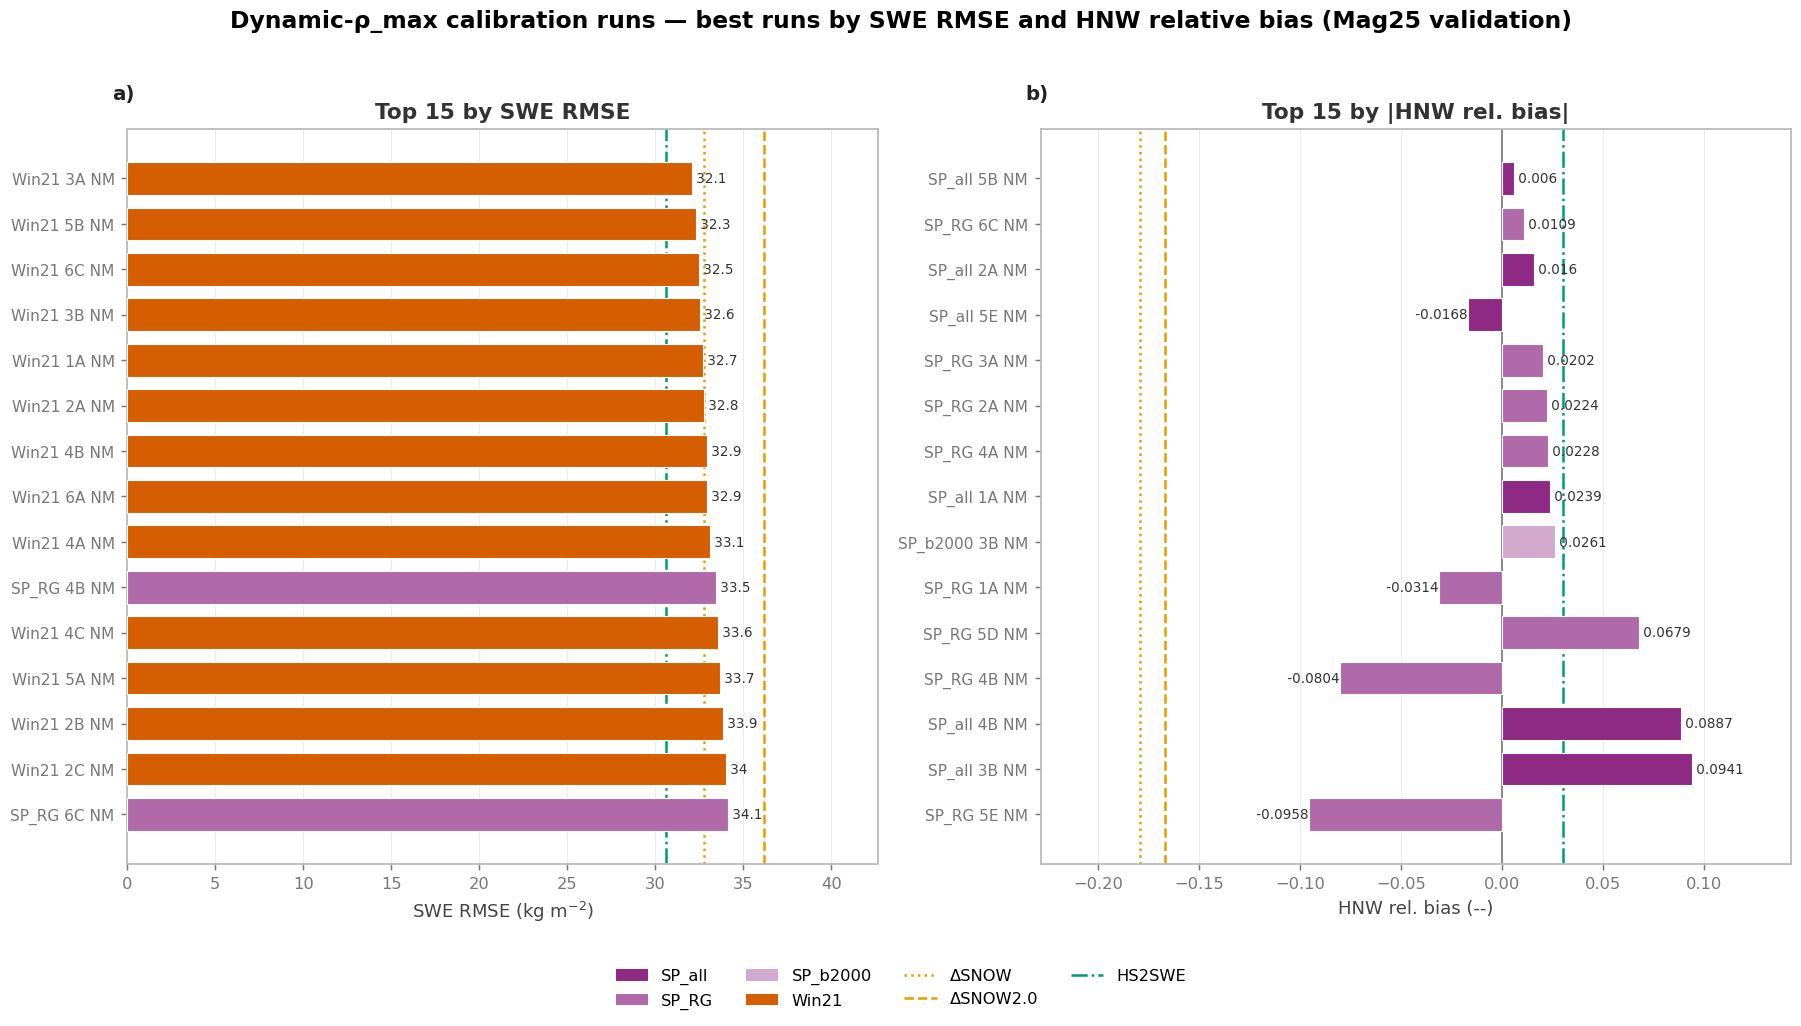

In [18]:
def ranking_bars(ax, sub, value_col, xlabel, ref_idx):
    y = np.arange(len(sub))[::-1]                      # best run on top
    for yi, (_, r) in zip(y, sub.iterrows()):
        ax.barh(yi, r[value_col], color=r["color"],
                edgecolor="white", linewidth=0.6, height=0.72, zorder=3)
        ax.text(r[value_col], yi, f" {r[value_col]:.3g}", va="center", ha="left" if r[value_col] >= 0 else "right",
                fontsize=7.5, color="#333333", zorder=4)
    for name, (swe, hnw) in REFS.items():
        ax.axvline((swe, hnw)[ref_idx], lw=1.4, zorder=2, **REF_STYLE[name])
    ax.set_yticks(y)
    ax.set_yticklabels(sub["run_label"], fontsize=8.5)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", color="#EBEBEB", lw=0.6); ax.grid(axis="y", visible=False)
    ax.margins(x=0.18)

_TOP_N  = 15
fig, axes = plt.subplots(1, 2, figsize=(14, max(3.5, 0.42 * _TOP_N + 1.5)))
ranking_bars(axes[0], df.sort_values("SWE_RMSE").head(_TOP_N),     "SWE_RMSE",     "SWE RMSE (kg m$^{-2}$)", 0)
ranking_bars(axes[1], df.sort_values("abs_HNW_bias").head(_TOP_N), "HNW_Rel_BIAS", "HNW rel. bias (--)",      1)
axes[1].axvline(0, color="grey", lw=1, zorder=2)
axes[0].set_title(f"Top {_TOP_N} by SWE RMSE", fontweight="semibold")
axes[1].set_title(f"Top {_TOP_N} by |HNW rel. bias|", fontweight="semibold")
add_subplot_labels(axes, x=-0.02, y=1.06)

subsets_present = [s for s in SUBSET_DISPLAY if s in df["subset"].values]
handles  = [Patch(facecolor=SUBSET_COL[s], label=SUBSET_DISPLAY[s]) for s in subsets_present]
handles += [Line2D([0], [0], lw=1.4, label=name, **REF_STYLE[name]) for name in REFS]
fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 4), frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Dynamic-ρ_max calibration runs — best runs by SWE RMSE and HNW relative bias (Mag25 validation)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0.06, 1, 0.97))
fig.savefig(PLOTS_DIR / "01_best_runs_bars.png", **FIG.SAVE)
plt.show()

---
## 3 — SWE RMSE vs HNW relative bias (all runs)

Every point = one calibration run. Stars = reference runs. Ring + label = the `TOP_N` runs by combined rank.

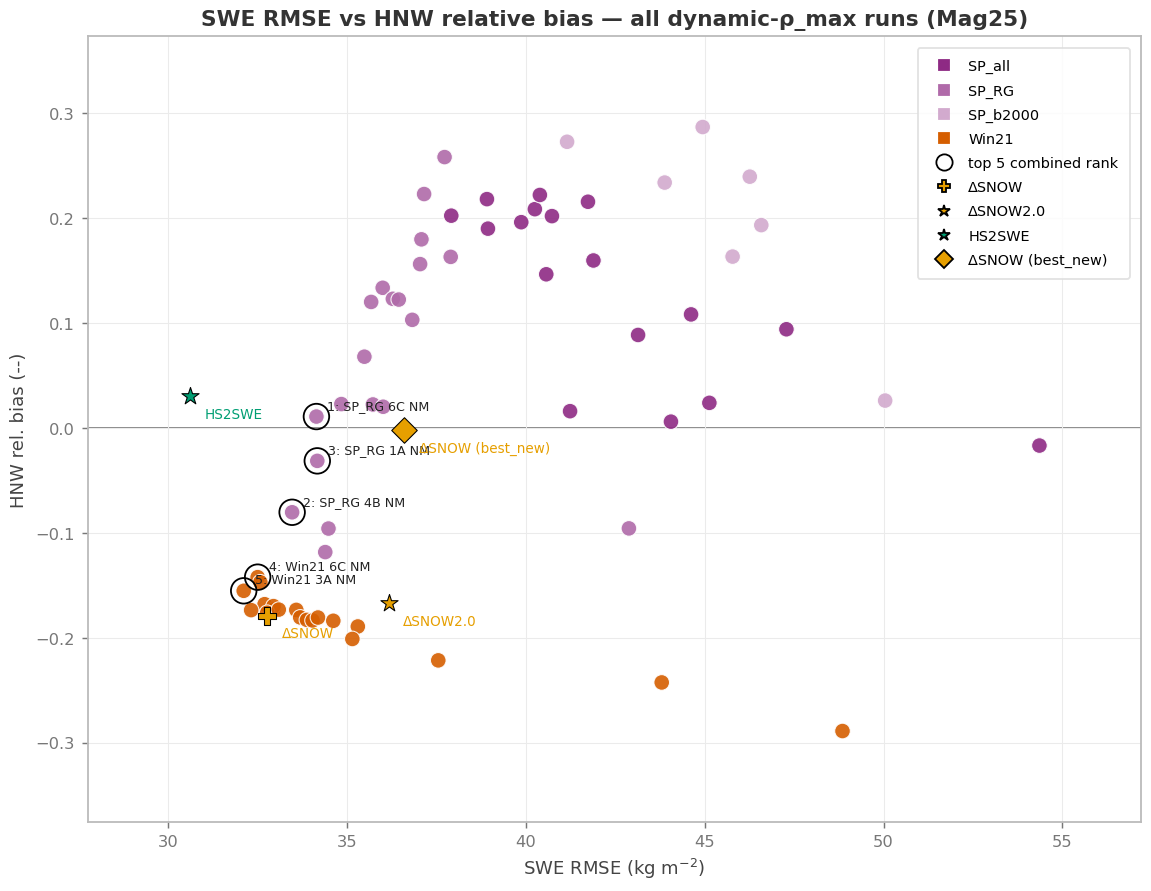

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.axhline(0, color="grey", lw=1, zorder=1)

ax.scatter(df["SWE_RMSE"], df["HNW_Rel_BIAS"], marker=RUN_MARKER, s=75, c=df["color"],
           edgecolor="white", linewidth=0.6, alpha=0.9, zorder=3)

# highlight + label the TOP_N combined runs
best = df.head(TOP_N)
ax.scatter(best["SWE_RMSE"], best["HNW_Rel_BIAS"], s=200, facecolor="none",
           edgecolor="k", linewidth=1.0, zorder=4)
for _, r in best.iterrows():
    ax.annotate(f"{int(r['rank'])}: {r['run_label']}", (r["SWE_RMSE"], r["HNW_Rel_BIAS"]),
                xytext=(6, 4), textcoords="offset points", fontsize=7, color="#222222", zorder=5)

# reference runs (+ ΔSNOW best_new, shown in this scatter only)
REFS_SCATTER = {**REFS, "ΔSNOW (best_new)": REF_DSNOW_BEST_NEW}
for name, (swe, hnw) in REFS_SCATTER.items():
    ax.scatter(swe, hnw, marker=REF_MARKER[name], s=100, color=REF_STYLE[name]["color"],
               edgecolor="k", linewidth=0.6, zorder=6)
    ax.annotate(name, (swe, hnw), xytext=(8, -12), textcoords="offset points",
                fontsize=7.5, color=REF_STYLE[name]["color"], zorder=6)

ax.set_xlabel("SWE RMSE (kg m$^{-2}$)")
ax.set_ylabel("HNW rel. bias (--)")
ax.set_title("SWE RMSE vs HNW relative bias — all dynamic-ρ_max runs (Mag25)", fontweight="semibold")
ax.margins(x=0.12, y=0.15)
ax.grid(axis="x", color="#EBEBEB", lw=0.6)

subsets_present = [s for s in SUBSET_DISPLAY if s in df["subset"].values]
handles  = [Line2D([0], [0], marker="s", ls="None", color=SUBSET_COL[s], markersize=6, label=SUBSET_DISPLAY[s])
            for s in subsets_present]
handles += [Line2D([0], [0], marker="o", ls="None", markerfacecolor="none", markeredgecolor="k", markersize=9,
                   label=f"top {TOP_N} combined rank")]
handles += [Line2D([0], [0], marker=REF_MARKER[n], ls="None", color=REF_STYLE[n]["color"], markeredgecolor="k",
                   markersize=7, label=n) for n in REFS_SCATTER]
ax.legend(handles=handles, loc="upper right", fontsize=8,
          labelspacing=0.7, borderpad=0.8, handletextpad=0.7, borderaxespad=0.8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "02_swe_rmse_vs_hnw_bias.png", **FIG.SAVE)
plt.show()

---
##  4 — Calibrated parameters per run

One panel per parameter, runs ordered by **combined rank** (best left). **Dashed line** = nixmass default
(calibration start value); Nelder-Mead is unconstrained, so the parameters can move freely from it.
σ, μ, ρ_h, ρ_l define the ρ_max(age) S-curve that replaces the constant ρ_max.

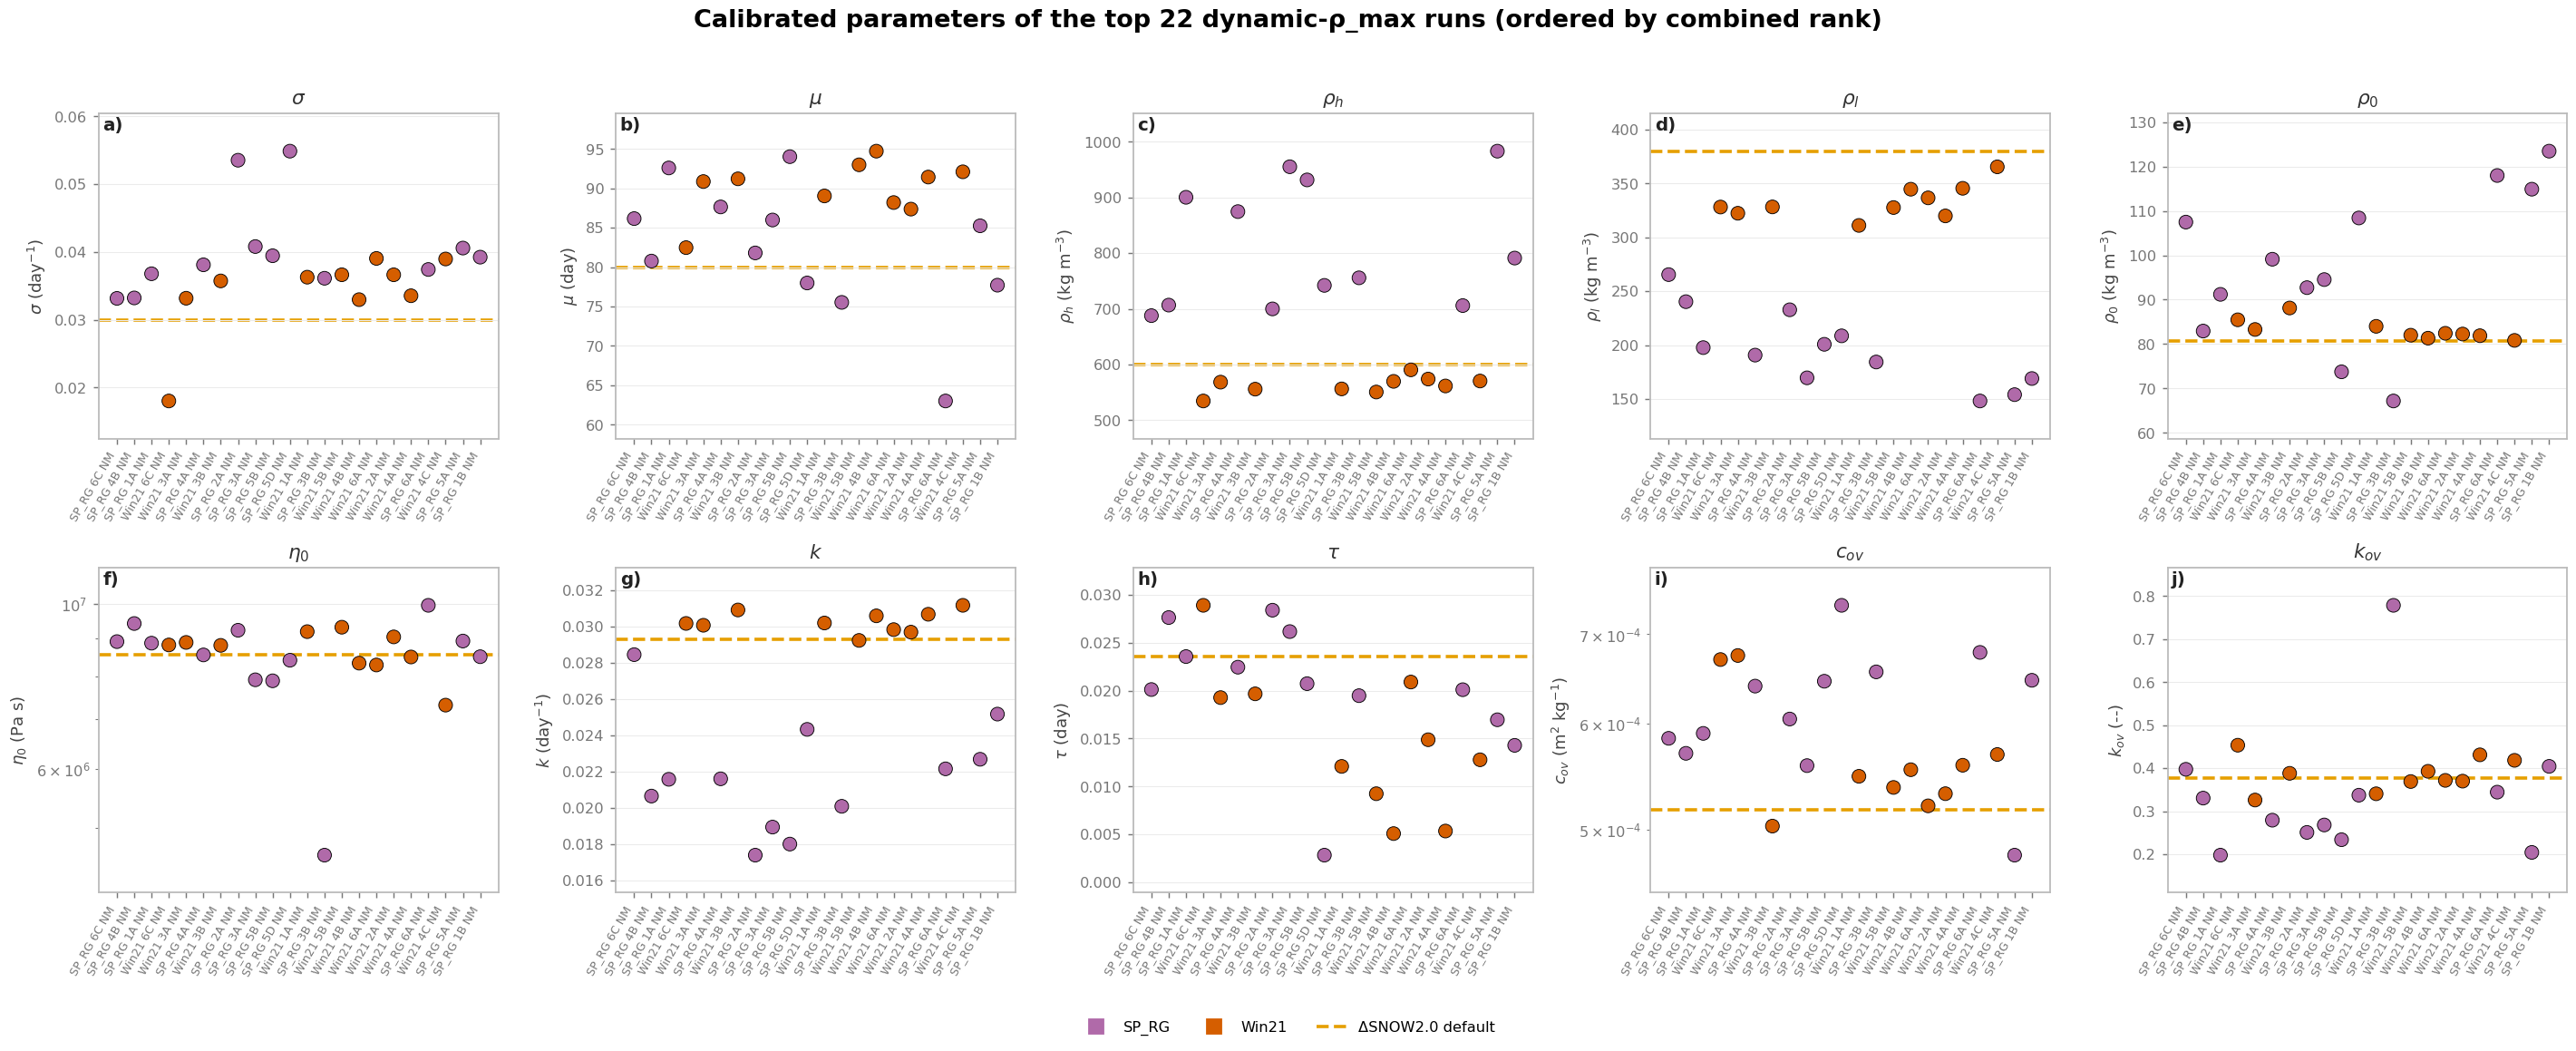

In [20]:
sub = df.head(TOP_N_PARAMS).reset_index(drop=True)
x = np.arange(len(sub))
PAD_FRAC = 0.15

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, p in zip(axes.flat, PARAMS):
    ax.axhline(DEFAULTS[p], color=C.DSNOW, ls="--", lw=2.0, zorder=1)
    ax.scatter(x, sub[p], marker=RUN_MARKER, s=70, c=sub["color"], edgecolor="k", linewidth=0.5, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["run_label"], rotation=60, ha="right", fontsize=7)
    ax.set_ylabel(PAR_LABEL[p])
    ax.set_title(PAR_LABEL[p].split(" (")[0], fontweight="semibold")

    vals = list(sub[p].values) + [DEFAULTS[p]]
    lo, hi = min(vals), max(vals)
    if p in LOG_PARS:
        ax.set_yscale("log")
        f = (hi / lo) ** PAD_FRAC
        ax.set_ylim(lo / f, hi * f)
    else:
        pad = PAD_FRAC * (hi - lo) if hi > lo else abs(hi) * PAD_FRAC
        ax.set_ylim(lo - pad, hi + pad)

add_subplot_labels(axes)

subsets_present = [s for s in SUBSET_DISPLAY if s in sub["subset"].values]
handles  = [Line2D([0], [0], marker="s", ls="None", color=SUBSET_COL[s], markersize=9, label=SUBSET_DISPLAY[s])
            for s in subsets_present]
handles += [Line2D([0], [0], color=C.DSNOW, ls="--", lw=2.0, label="ΔSNOW2.0 default")]
fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, 0.0))
fig.suptitle(f"Calibrated parameters of the top {len(sub)} dynamic-ρ_max runs (ordered by combined rank)",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0.05, 1, 0.96))
fig.savefig(PLOTS_DIR / "03_parameters_top_runs.png", **FIG.SAVE)
plt.show()

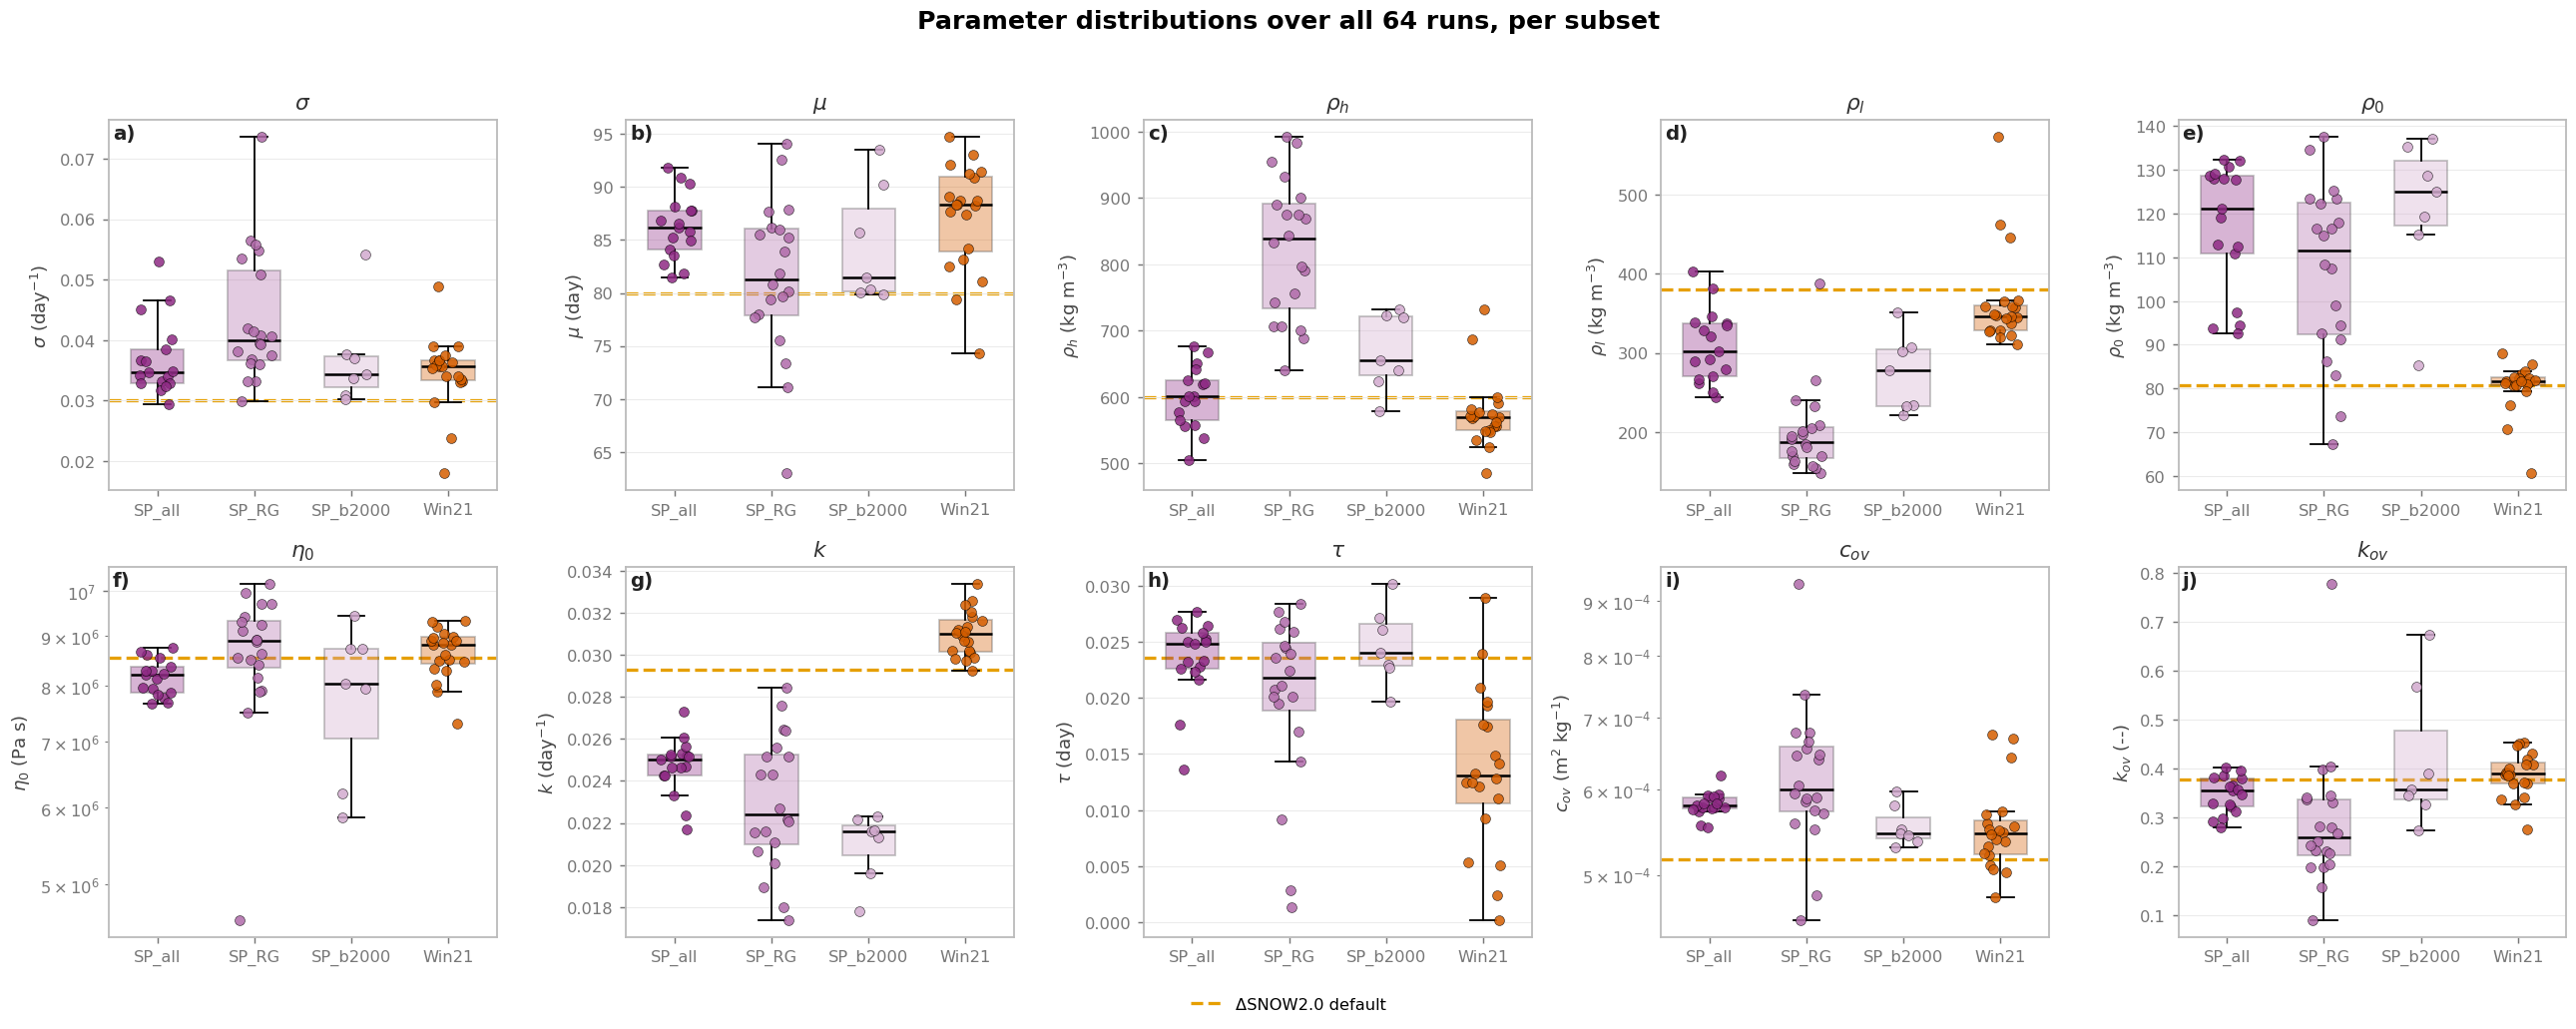

In [21]:
subsets_present = [s for s in SUBSET_DISPLAY if s in df["subset"].values]
rng = np.random.default_rng(0)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, p in zip(axes.flat, PARAMS):
    ax.axhline(DEFAULTS[p], color=C.DSNOW, ls="--", lw=1.8, zorder=1)

    data = [df.loc[df["subset"] == s, p].values for s in subsets_present]
    bp = ax.boxplot(data, positions=range(len(subsets_present)), widths=0.55,
                    patch_artist=True, showfliers=False, zorder=2)
    for patch, s in zip(bp["boxes"], subsets_present):
        patch.set_facecolor(SUBSET_COL[s]); patch.set_alpha(0.35); patch.set_edgecolor("#555555")
    for i, s in enumerate(subsets_present):
        v = df.loc[df["subset"] == s, p].values
        ax.scatter(i + rng.uniform(-0.18, 0.18, len(v)), v, marker=RUN_MARKER, s=30, c=SUBSET_COL[s],
                   edgecolor="k", linewidth=0.3, alpha=0.85, zorder=3)
    ax.set_xticks(range(len(subsets_present)))
    ax.set_xticklabels([SUBSET_DISPLAY[s] for s in subsets_present])
    if p in LOG_PARS:
        ax.set_yscale("log")
    ax.set_ylabel(PAR_LABEL[p])
    ax.set_title(PAR_LABEL[p].split(" (")[0], fontweight="semibold")
add_subplot_labels(axes)

handles = [Line2D([0], [0], color=C.DSNOW, ls="--", lw=1.8, label="ΔSNOW2.0 default")]
fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, 0.0))
fig.suptitle(f"Parameter distributions over all {len(df)} runs, per subset", fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
fig.savefig(PLOTS_DIR / "04b_parameter_distributions.png", **FIG.SAVE)
plt.show()

---
## 5 — Resulting ρ_max(age)

$\rho_{\max}(t) = \arctan\!\big(\sigma\,(t-\mu)\big)\,\dfrac{\rho_h-\rho_l}{\pi} + \dfrac{\rho_h+\rho_l}{2}$

Left: every run (thin lines, colour = subset). Right: the `TOP_N` runs by combined rank. Dashed amber = nixmass
default S-curve, dotted grey = constant ρ_max of the original model (401.26 kg m⁻³).

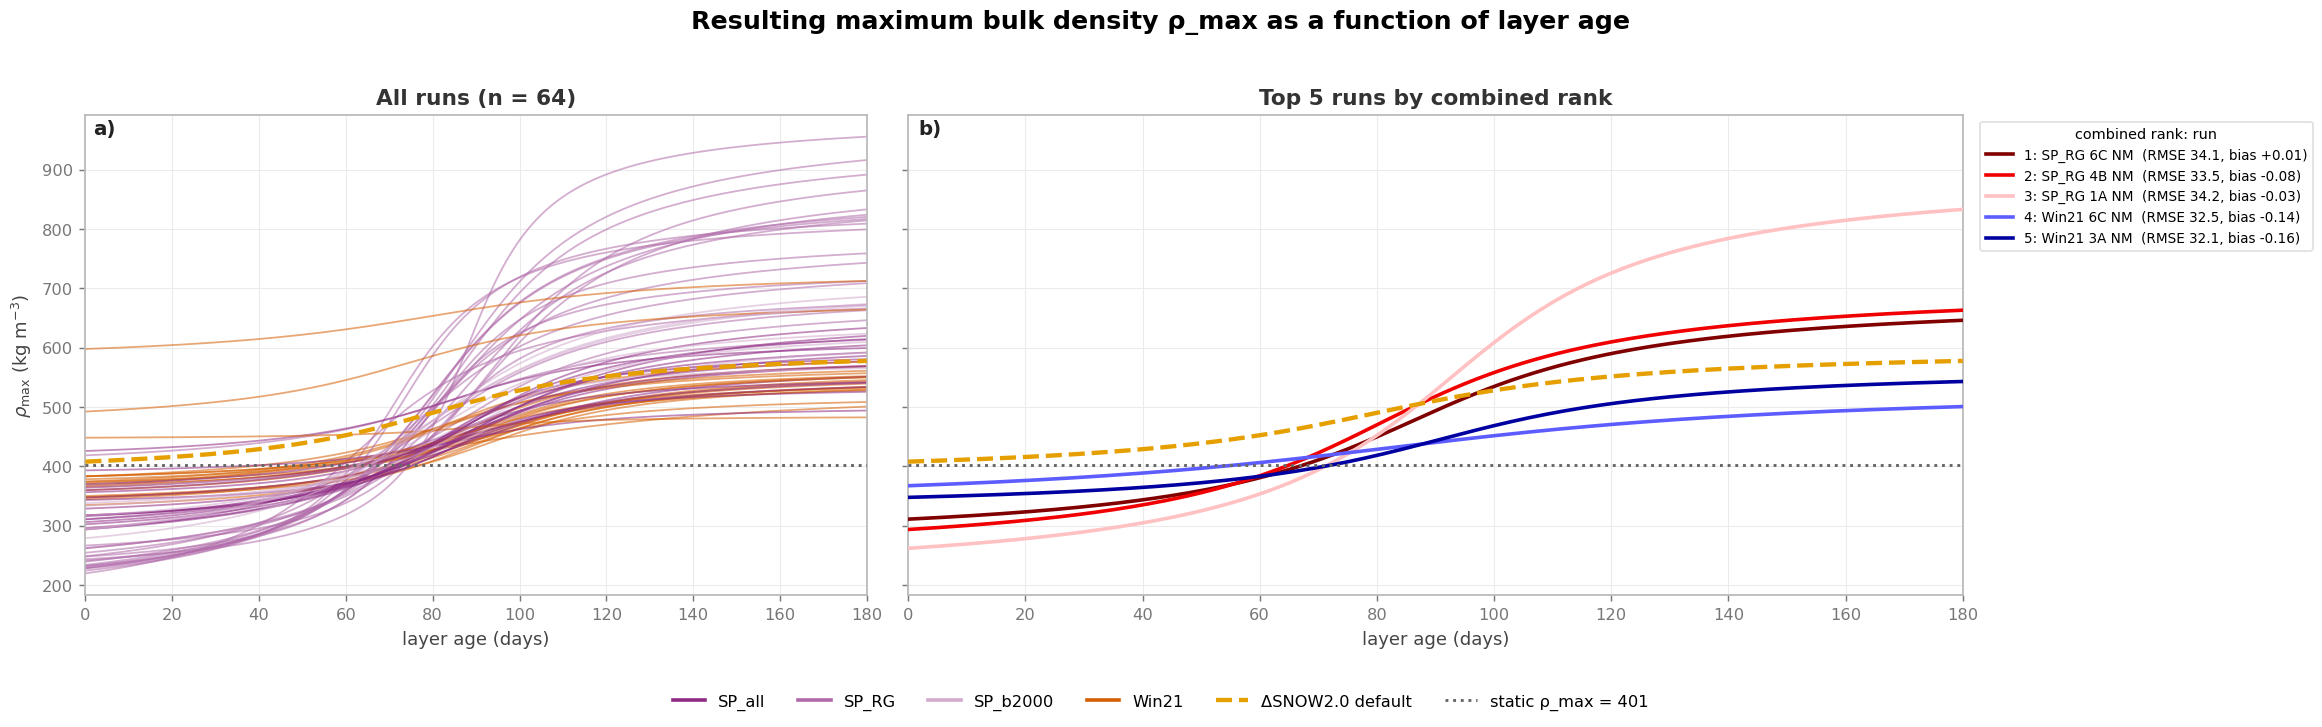

In [22]:
age = np.arange(0, AGE_MAX_DAYS + 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), sharey=True, gridspec_kw={"width_ratios": [1, 1.35]})

# a) all runs
ax = axes[0]
for _, r in df.iterrows():
    ax.plot(age, rho_max_dyn(age, r["sigma"], r["mu"], r["rho_h"], r["rho_l"]),
            color=r["color"], lw=1.0, alpha=0.55, ls="-", zorder=2)
ax.set_title(f"All runs (n = {len(df)})", fontweight="semibold")

# b) top runs by combined rank
ax = axes[1]
best = df.head(5)
colors = plt.get_cmap("seismic_r")(np.linspace(0, 0.88, max(len(best), 2)))   # skip the pale yellow end
for i, (_, r) in enumerate(best.iterrows()):
    ax.plot(age, rho_max_dyn(age, r["sigma"], r["mu"], r["rho_h"], r["rho_l"]),
            color=colors[i], lw=2.0, ls="-",
            label=f"{int(r['rank'])}: {r['run_label']}  (RMSE {r['SWE_RMSE']:.1f}, bias {r['HNW_Rel_BIAS']:+.2f})", zorder=3)
ax.set_title(f"Top {len(best)} runs by combined rank", fontweight="semibold")
ax.legend(fontsize=7.5, loc="upper left", bbox_to_anchor=(1.01, 1.0), title="combined rank: run", title_fontsize=8)

for ax in axes:
    ax.plot(age, rho_max_dyn(age, DEFAULTS["sigma"], DEFAULTS["mu"], DEFAULTS["rho_h"], DEFAULTS["rho_l"]),
            color=C.DSNOW, ls="--", lw=2.4, zorder=4)
    ax.axhline(RHO_MAX_STATIC, color="#666666", ls=":", lw=1.6, zorder=4)
    ax.set_xlabel("layer age (days)")
    ax.set_xlim(0, AGE_MAX_DAYS)
    ax.grid(axis="x", color="#EBEBEB", lw=0.6)
axes[0].set_ylabel(r"$\rho_{\max}$ (kg m$^{-3}$)")
add_subplot_labels(axes)

subsets_present = [s for s in SUBSET_DISPLAY if s in df["subset"].values]
handles  = [Line2D([0], [0], color=SUBSET_COL[s], lw=2, label=SUBSET_DISPLAY[s]) for s in subsets_present]
handles += [Line2D([0], [0], color=C.DSNOW,   lw=2.4, ls="--", label="ΔSNOW2.0 default"),
            Line2D([0], [0], color="#666666", lw=1.6, ls=":",  label=f"static ρ_max = {RHO_MAX_STATIC:.0f}")]
fig.legend(handles=handles, loc="lower center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Resulting maximum bulk density ρ_max as a function of layer age", fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0.06, 1, 0.96))
fig.savefig(PLOTS_DIR / "05_rho_max_age_curves.png", **FIG.SAVE)
plt.show()

In [23]:
best = df.head(20).copy()
best["rho_max_0d"]  = rho_max_dyn(0,            best["sigma"], best["mu"], best["rho_h"], best["rho_l"])
best["rho_max_mu"]  = (best["rho_h"] + best["rho_l"]) / 2
best["rho_max_end"] = rho_max_dyn(AGE_MAX_DAYS, best["sigma"], best["mu"], best["rho_h"], best["rho_l"])
best["width_days"]  = 2 / best["sigma"]
cols = ["rank", "run_label", "sigma", "mu", "rho_l", "rho_h",
        "rho_max_0d", "rho_max_mu", "rho_max_end", "width_days", "SWE_RMSE", "HNW_Rel_BIAS"]
best[cols].set_index("rank")

,run_label,sigma,mu,rho_l,rho_h,rho_max_0d,rho_max_mu,rho_max_end,width_days,SWE_RMSE,HNW_Rel_BIAS
rank,,,,,,,,,,,
1,SP_RG 6C NM,0.033151,86.167200,265.428483,687.750259,310.696254,476.589371,645.937373,60.329768,34.142230,0.010872
2,SP_RG 4B NM,0.033218,80.773826,240.311660,706.672946,293.269682,473.492303,662.946289,60.207580,33.463357,-0.080394
3,SP_RG 1A NM,0.036784,92.599148,197.679691,900.338104,261.549974,549.008897,832.889414,54.372152,34.166672,-0.031381
4,Win21 6C NM,0.018019,82.479214,328.133977,534.445851,367.030268,431.289914,500.468738,110.996609,32.499706,-0.142264
5,Win21 3A NM,0.033174,90.872916,322.359004,568.287115,347.432250,445.323060,542.756533,60.288464,32.109705,-0.155275
6,SP_RG 4A NM,0.038102,87.649098,190.724807,874.631140,254.060165,532.677974,814.354042,52.490221,34.839781,0.022782
7,Win21 3B NM,0.035728,91.216792,328.255727,555.688339,349.809142,441.972033,533.579754,55.978605,32.574847,-0.147152
8,SP_RG 2A NM,0.053530,81.808763,232.795275,699.866774,266.172861,466.331024,671.915225,37.362390,35.721977,0.022394
9,SP_RG 3A NM,0.040797,85.990778,169.636919,955.229415,239.075922,562.433167,891.448659,49.023696,36.008570,0.020218


---
## 6 — Validation scatter for one run (pick by combined rank)



In [24]:
import hnw_validation_helper as val_helper   # ROOT is on sys.path

DSNOW = "Δꜱɴᴏᴡ"   # Δꜱɴᴏᴡ (small caps, as in the manuscript)

def plot_run_validation(rank, cmap="viridis", save=False):
    """HNW + SWE validation scatter (Mag25) of the run with this combined rank."""
    r  = df.loc[df["rank"] == rank].iloc[0]
    ds = xr.open_dataset(ROOT / r["nc_file"])
    ds = ds.assign_coords(station=[v.decode().strip() if isinstance(v, bytes) else str(v).strip()
                                   for v in ds["station_name"].values])
    long = ds[["HNW_obs", "HNW_mod", "SWE_obs", "SWE_mod"]].to_dataframe().reset_index()

    return val_helper.validate_hnw_swe_combined(
        hnw_df     = long[long["HNW_obs"].notna()],
        swe_df     = long[long["SWE_obs"].notna()],
        model_name = f"{DSNOW} {r['run_label']}   (combined rank {rank})",
        params     = {p: r[p] for p in PARAMS},
        save_dir   = PLOTS_DIR if save else None,
        filename   = f"validation_rank{rank:02d}_{r['subset']}_{r['phase']}_{r['alg_short']}.png",
        cmap       = cmap,
    )

In [25]:
PAR_UNIT = {"sigma": "day⁻¹", "mu": "day", "rho_h": "kg m⁻³", "rho_l": "kg m⁻³", "rho_null": "kg m⁻³",
            "eta_null": "Pa s", "k": "m³ kg⁻¹", "tau": "m", "c_ov": "–", "k_ov": "–"}

def _fmt(v):
    return f"{v:.4g}" if 1e-2 <= abs(v) < 1e5 else f"{v:.3e}"

def param_change_table(rank):
    """Calibrated parameters of one run vs. the ΔSnow 2.0 defaults: how much each rises / falls."""
    r = df.loc[df["rank"] == rank].iloc[0]
    t = pd.DataFrame({
        "unit":       [PAR_UNIT[p] for p in PARAMS],
        "default":    [DEFAULTS[p] for p in PARAMS],
        "calibrated": [r[p] for p in PARAMS],
    }, index=pd.Index(PARAMS, name=f"rank {rank}: {r['run_label']}"))
    t["change"]   = t["calibrated"] - t["default"]
    t["change_%"] = 100 * t["change"] / t["default"]
    t["trend"]    = np.where(t["change"] > 0, "↑ rises", np.where(t["change"] < 0, "↓ falls", "= unchanged"))
    return (t.style
             .format({"default": _fmt, "calibrated": _fmt, "change": lambda v: f"{v:+.3g}", "change_%": "{:+.1f} %"})
             .bar(subset=["change_%"], align="zero", color=["#D55E00", "#009E73"], width=60))

HNW stats: {'RMSE': np.float64(2.9339440613406906), 'Bias': np.float64(0.022251557250055443), 'Rel_BIAS': np.float64(0.010872159385500388), 'R2': np.float64(0.8319063648712484), 'N': 35409}
SWE stats: {'RMSE': np.float64(34.14222986330403), 'Bias': np.float64(9.69716538361973), 'Rel_BIAS': np.float64(0.04879363419873182), 'R2': np.float64(0.9214939758798233), 'N': 1054}


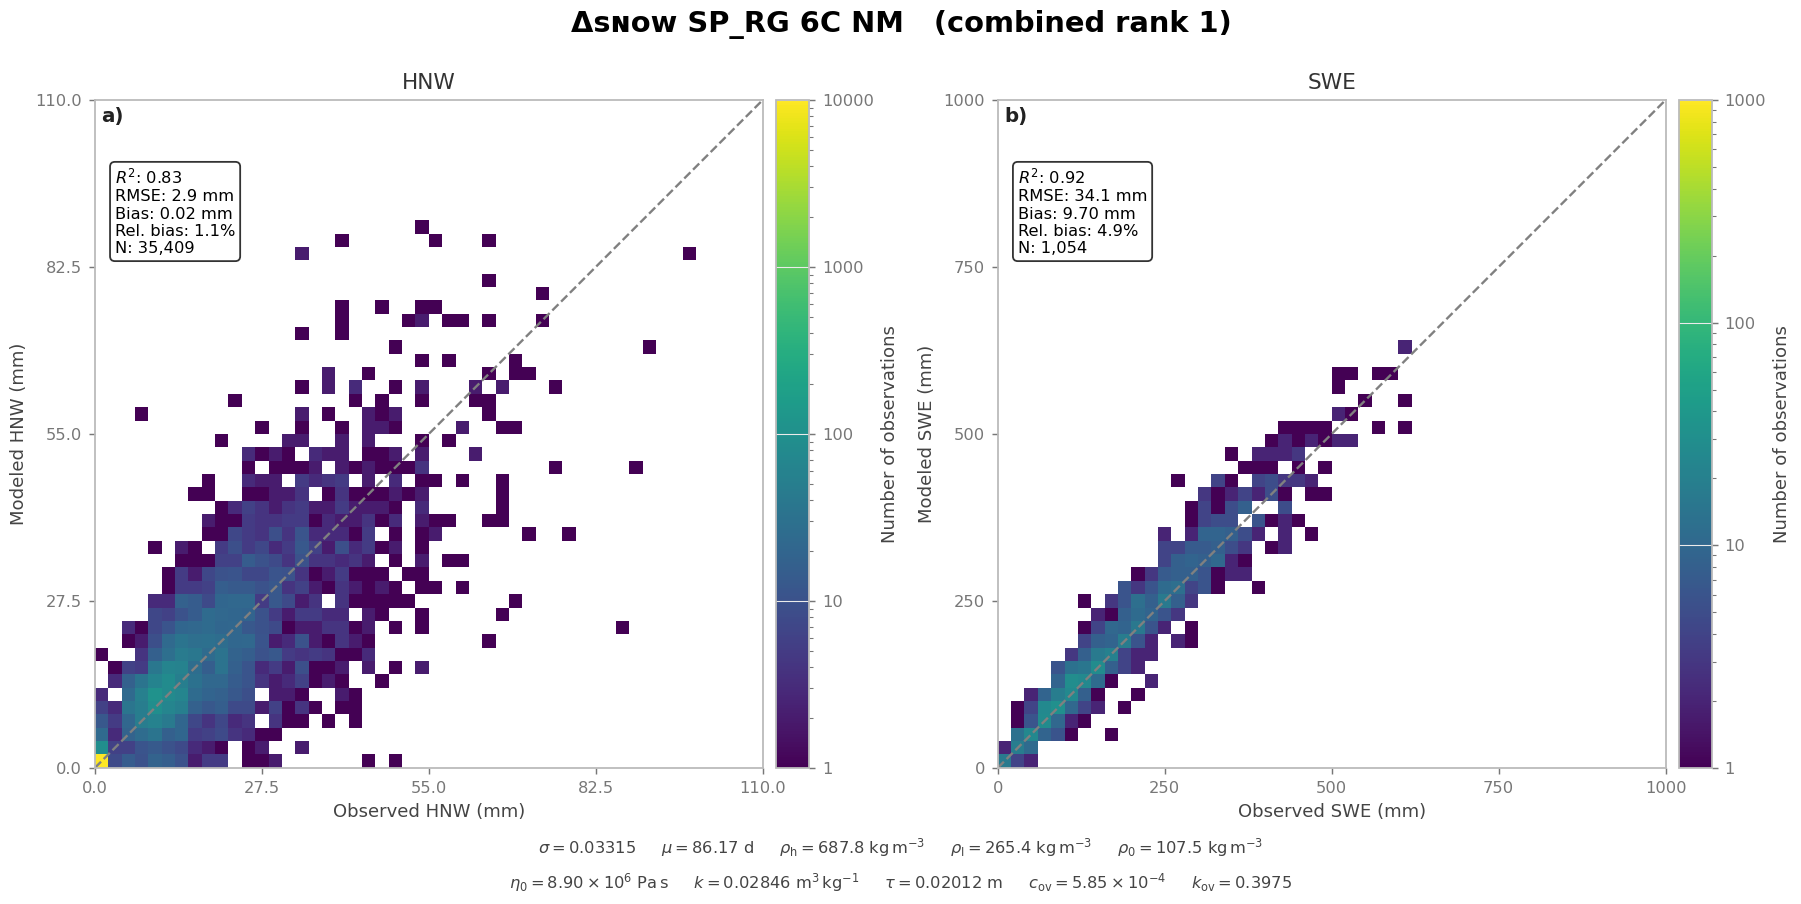

,unit,default,calibrated,change,change_%,trend
rank 1: SP_RG 6C NM,,,,,,
sigma,day⁻¹,0.03,0.03315,+0.00315,+10.5 %,↑ rises
mu,day,80,86.17,+6.17,+7.7 %,↑ rises
rho_h,kg m⁻³,600,687.8,+87.8,+14.6 %,↑ rises
rho_l,kg m⁻³,380,265.4,-115,-30.2 %,↓ falls
rho_null,kg m⁻³,80.74,107.5,+26.7,+33.1 %,↑ rises
eta_null,Pa s,8.544e+06,8.900e+06,+3.57e+05,+4.2 %,↑ rises
k,m³ kg⁻¹,0.0293,0.02846,-0.000841,-2.9 %,↓ falls
tau,m,0.02357,0.02012,-0.00345,-14.6 %,↓ falls
c_ov,–,5.171e-04,5.851e-04,+6.8e-05,+13.2 %,↑ rises


In [27]:
number_rank = 1

stats = plot_run_validation(rank=number_rank)
param_change_table(rank=number_rank)